# AI013 Wildfire Time Series Forecasting: Baseline Fire Intensity Forecasting

This notebook contributes to the AI013 time series forecasting task by preparing a baseline forecasting workflow for wildfire fire intensity.

The main dataset used is wildfire_multi_region_dataset.csv. The timestamp column is acq_date, the location column is region, and the target variable is frp_mw, which represents Fire Radiative Power in megawatts.

The aim of this notebook is not to replace the main LSTM model. Instead, this work provides a clean baseline forecasting and feature preparation workflow that can later be compared with more advanced models such as LSTM.




## 1. Import Required Libraries

The required Python libraries are imported for data processing, visualisation, feature preparation, model building and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Load the Wildfire Dataset

The wildfire dataset is loaded into a pandas DataFrame. This dataset is used because it contains time-based wildfire observations and includes frp_mw which can be used as the forecasting target for fire intensity.

In [2]:
df = pd.read_csv("wildfire_multi_region_dataset.csv")

df.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
0,-16.7722,151.0241,2024-01-01,1133,2024,1,Summer,D,Australia,Australia,...,TERRA,MODIS,347.72,29.38,Moderate,high,42.1,1.7,0.47,18.4
1,-41.1960,130.1397,2024-01-01,1251,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,357.82,62.05,High,nominal,43.8,2.2,0.27,11.7
2,-39.8750,124.9104,2024-01-02,1326,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,333.76,3.35,Low,high,35.4,4.4,0.35,5.0
3,-10.0978,149.8371,2024-01-02,206,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,323.94,46.35,Moderate,high,39.6,34.7,0.30,39.1
4,-12.4540,119.2301,2024-01-02,2054,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,359.59,434.80,Extreme,high,46.7,16.7,6.49,53.1


## 3. Dataset Overview

Before preparing the forecasting dataset, the structure of the data is checked. This includes the number of rows and columns, available variables, data types and missing values.

In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (15500, 21)

Columns:
['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month', 'season', 'daynight', 'region', 'country', 'fire_type', 'satellite', 'instrument', 'brightness_k', 'frp_mw', 'fire_intensity', 'confidence', 'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        15500 non-null  float64
 1   longitude       15500 non-null  float64
 2   acq_date        15500 non-null  object 
 3   acq_time        15500 non-null  int64  
 4   year            15500 non-null  int64  
 5   month           15500 non-null  int64  
 6   season          15500 non-null  object 
 7   daynight        15500 non-null  object 
 8   region          15500 non-null  object 
 9   country         15500 non-null  object 
 10  fire_type       15500 non-null  object 
 11  satellite       15500 non-null  object 
 12  instrument      15500 non-null  object 
 13  brightness_k    15500 non-null  float64
 14  frp_mw          15500 non-null  float64
 15  fire_intensity  15500 non-null  object 
 16  confidence      15500 non-null  object 
 17  temp_max_c      15500 non-null 

In [5]:
df.isnull().sum()

,0
latitude,0
longitude,0
acq_date,0
acq_time,0
year,0
month,0
season,0
daynight,0
region,0
country,0


In [6]:
df.describe()

,latitude,longitude,acq_time,year,month,brightness_k,frp_mw,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000
mean,10.251489,29.204768,1177.268645,2024.503032,7.244774,336.501241,80.181982,35.099335,17.783774,2.595579,38.136716
std,24.367098,78.693275,689.540417,0.500007,2.768195,19.209340,150.411669,5.850954,17.617369,3.154769,18.890952
min,-42.990800,-167.990600,0.000000,2024.000000,1.000000,290.000000,0.370000,12.800000,0.000000,0.000000,5.000000
25%,-7.561575,-41.641000,600.000000,2024.000000,5.000000,324.570000,15.010000,31.000000,5.100000,0.610000,24.300000
50%,10.477350,34.807950,1200.000000,2025.000000,8.000000,335.170000,35.445000,35.200000,12.500000,1.520000,36.300000
75%,30.104450,95.064200,1756.000000,2025.000000,9.000000,346.670000,83.720000,39.200000,24.700000,3.330000,50.800000
max,69.982600,153.987500,2359.000000,2025.000000,12.000000,574.860000,3000.000000,55.500000,188.800000,34.440000,95.000000


## 4. Timestamp and Location Preparation

For this forecasting task, acq_date is used as the timestamp and region is used as the location field. The date column is converted into datetime format so it can be used for time series grouping and analysis.

In [7]:
df["acq_date"] = pd.to_datetime(df["acq_date"], errors="coerce")

print("Minimum date:", df["acq_date"].min())
print("Maximum date:", df["acq_date"].max())

Minimum date: 2024-01-01 00:00:00
Maximum date: 2025-12-31 00:00:00


In [8]:
df[["acq_date", "region"]].head()

,acq_date,region
0,2024-01-01,Australia
1,2024-01-01,Australia
2,2024-01-02,Australia
3,2024-01-02,Australia
4,2024-01-02,Australia


## 5. Filter Dataset for Australia

The team lead's notebook focuses on Australia, so this notebook follows the same direction. Filtering the dataset to one region keeps the baseline forecasting workflow simple and clear.

In this version, location is still kept as part of the feature preparation logic, but the model focuses only on Australian wildfire observations.

In [9]:
aus_df = df[df["region"].astype(str).str.lower() == "australia"].copy()

print("Australia dataset shape:", aus_df.shape)
aus_df.head()

Australia dataset shape: (900, 21)


,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
0,-16.7722,151.0241,2024-01-01,1133,2024,1,Summer,D,Australia,Australia,...,TERRA,MODIS,347.72,29.38,Moderate,high,42.1,1.7,0.47,18.4
1,-41.1960,130.1397,2024-01-01,1251,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,357.82,62.05,High,nominal,43.8,2.2,0.27,11.7
2,-39.8750,124.9104,2024-01-02,1326,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,333.76,3.35,Low,high,35.4,4.4,0.35,5.0
3,-10.0978,149.8371,2024-01-02,206,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,323.94,46.35,Moderate,high,39.6,34.7,0.30,39.1
4,-12.4540,119.2301,2024-01-02,2054,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,359.59,434.80,Extreme,high,46.7,16.7,6.49,53.1


## 6. Daily Time Series Aggregation

The original dataset may contain multiple wildfire observations for the same date. To prepare a daily forecasting dataset, the records are grouped by date and region.

The target variable is `frp_mw`, which represents fire intensity. For each day, the total fire intensity is calculated. Other hazard-related variables are aggregated using suitable summary statistics.

In [10]:
daily_df = aus_df.groupby(["acq_date", "region"]).agg(
    frp_mw=("frp_mw", "sum"),
    event_count=("frp_mw", "count"),
    avg_brightness_k=("brightness_k", "mean"),
    avg_temp_max_c=("temp_max_c", "mean"),
    avg_wind_max_kmh=("wind_max_kmh", "mean"),
    avg_precip_mm=("precip_mm", "mean"),
    avg_humidity_pct=("humidity_pct", "mean")
).reset_index()

daily_df = daily_df.sort_values("acq_date")

daily_df.head()

,acq_date,region,frp_mw,event_count,avg_brightness_k,avg_temp_max_c,avg_wind_max_kmh,avg_precip_mm,avg_humidity_pct
0,2024-01-01,Australia,91.43,2,352.770000,42.950000,1.950000,0.370000,15.050000
1,2024-01-02,Australia,641.35,5,338.190000,41.880000,14.560000,1.532000,24.880000
2,2024-01-03,Australia,86.07,2,334.475000,40.900000,8.200000,0.690000,20.450000
3,2024-01-04,Australia,141.71,3,342.223333,37.433333,43.666667,1.160000,8.966667
4,2024-01-05,Australia,926.33,7,335.620000,43.028571,15.500000,1.358571,21.700000


## 7. Create Continuous Daily Date Range

A time series model works better when the data has regular time intervals. Therefore, a complete daily date range is created. Dates without recorded wildfire activity are filled with zero fire intensity and zero event count.

Weather-related values are forward-filled where possible because they are continuous environmental features.

In [11]:
full_dates = pd.date_range(
    start=daily_df["acq_date"].min(),
    end=daily_df["acq_date"].max(),
    freq="D"
)

full_df = pd.DataFrame({"acq_date": full_dates})
full_df["region"] = "Australia"

daily_df = full_df.merge(daily_df, on=["acq_date", "region"], how="left")

daily_df["frp_mw"] = daily_df["frp_mw"].fillna(0)
daily_df["event_count"] = daily_df["event_count"].fillna(0)

weather_cols = [
    "avg_brightness_k",
    "avg_temp_max_c",
    "avg_wind_max_kmh",
    "avg_precip_mm",
    "avg_humidity_pct"
]

daily_df[weather_cols] = daily_df[weather_cols].ffill().bfill()

daily_df.head()

,acq_date,region,frp_mw,event_count,avg_brightness_k,avg_temp_max_c,avg_wind_max_kmh,avg_precip_mm,avg_humidity_pct
0,2024-01-01,Australia,91.43,2.0,352.770000,42.950000,1.950000,0.370000,15.050000
1,2024-01-02,Australia,641.35,5.0,338.190000,41.880000,14.560000,1.532000,24.880000
2,2024-01-03,Australia,86.07,2.0,334.475000,40.900000,8.200000,0.690000,20.450000
3,2024-01-04,Australia,141.71,3.0,342.223333,37.433333,43.666667,1.160000,8.966667
4,2024-01-05,Australia,926.33,7.0,335.620000,43.028571,15.500000,1.358571,21.700000


In [12]:
daily_df.isnull().sum()

,0
acq_date,0
region,0
frp_mw,0
event_count,0
avg_brightness_k,0
avg_temp_max_c,0
avg_wind_max_kmh,0
avg_precip_mm,0
avg_humidity_pct,0


## 8. Target Variable Visualisation

The target variable for this notebook is daily frp_mw. Plotting this variable helps show how fire intensity changes over time and whether there are any spikes or visible patterns.

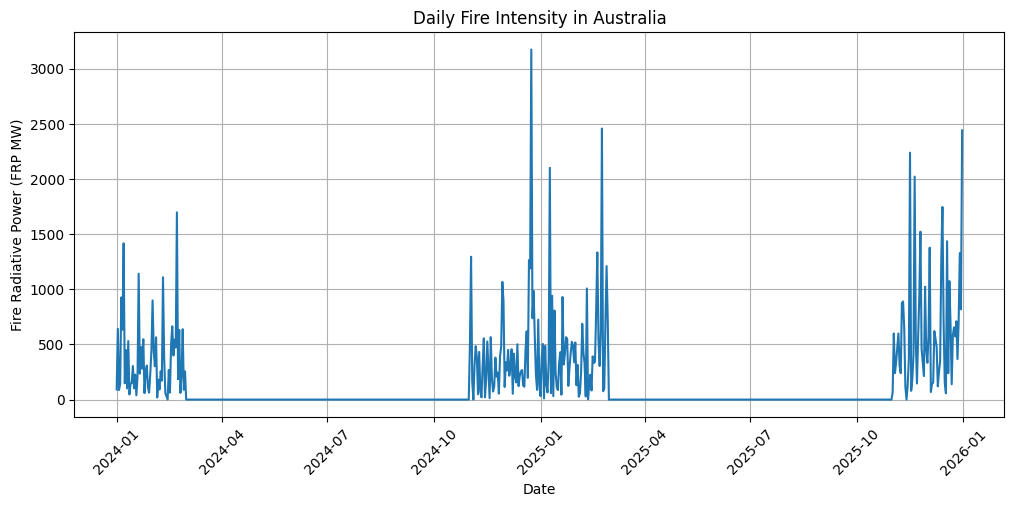

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(daily_df["acq_date"], daily_df["frp_mw"])
plt.title("Daily Fire Intensity in Australia")
plt.xlabel("Date")
plt.ylabel("Fire Radiative Power (FRP MW)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## 9. Basic Time-Based Features

Time-based features are created from the timestamp. These features help the model understand calendar patterns such as month, day of week and weekends.

In [14]:
daily_df["day_of_week"] = daily_df["acq_date"].dt.dayofweek
daily_df["month"] = daily_df["acq_date"].dt.month
daily_df["is_weekend"] = daily_df["day_of_week"].isin([5, 6]).astype(int)

daily_df[["acq_date", "day_of_week", "month", "is_weekend"]].head()

,acq_date,day_of_week,month,is_weekend
0,2024-01-01,0,1,0
1,2024-01-02,1,1,0
2,2024-01-03,2,1,0
3,2024-01-04,3,1,0
4,2024-01-05,4,1,0


## 10. Lag and Rolling Average Features

Lag and rolling average features are common in time series forecasting. A lag feature uses previous values of the target variable, while a rolling average smooths recent values.

These features are useful because wildfire intensity on a given day may be influenced by recent wildfire activity.

In [15]:
daily_df["frp_lag_1"] = daily_df["frp_mw"].shift(1)
daily_df["frp_lag_3"] = daily_df["frp_mw"].shift(3)
daily_df["frp_lag_7"] = daily_df["frp_mw"].shift(7)

daily_df["frp_rolling_3_mean"] = daily_df["frp_mw"].shift(1).rolling(window=3).mean()
daily_df["frp_rolling_7_mean"] = daily_df["frp_mw"].shift(1).rolling(window=7).mean()
daily_df["frp_rolling_14_mean"] = daily_df["frp_mw"].shift(1).rolling(window=14).mean()

daily_df.head(15)

,acq_date,region,frp_mw,event_count,avg_brightness_k,avg_temp_max_c,avg_wind_max_kmh,avg_precip_mm,avg_humidity_pct,day_of_week,month,is_weekend,frp_lag_1,frp_lag_3,frp_lag_7,frp_rolling_3_mean,frp_rolling_7_mean,frp_rolling_14_mean
0,2024-01-01,Australia,91.43,2.0,352.770000,42.950000,1.950000,0.370000,15.050000,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,Australia,641.35,5.0,338.190000,41.880000,14.560000,1.532000,24.880000,1,1,0,91.43,NaN,NaN,NaN,NaN,NaN
2,2024-01-03,Australia,86.07,2.0,334.475000,40.900000,8.200000,0.690000,20.450000,2,1,0,641.35,NaN,NaN,NaN,NaN,NaN
3,2024-01-04,Australia,141.71,3.0,342.223333,37.433333,43.666667,1.160000,8.966667,3,1,0,86.07,91.43,NaN,272.950000,NaN,NaN
4,2024-01-05,Australia,926.33,7.0,335.620000,43.028571,15.500000,1.358571,21.700000,4,1,0,141.71,641.35,NaN,289.710000,NaN,NaN
5,2024-01-06,Australia,633.05,4.0,341.135000,39.600000,14.025000,1.162500,12.800000,5,1,1,926.33,86.07,NaN,384.703333,NaN,NaN
6,2024-01-07,Australia,1415.96,4.0,352.570000,37.450000,9.550000,1.977500,20.550000,6,1,1,633.05,141.71,NaN,567.030000,NaN,NaN
7,2024-01-08,Australia,147.99,3.0,329.973333,37.200000,12.700000,0.396667,21.066667,0,1,0,1415.96,926.33,91.43,991.780000,562.271429,NaN
8,2024-01-09,Australia,449.29,4.0,343.000000,38.500000,12.525000,3.322500,15.275000,1,1,0,147.99,633.05,641.35,732.333333,570.351429,NaN
9,2024-01-10,Australia,101.34,1.0,305.680000,38.400000,0.900000,1.720000,10.700000,2,1,0,449.29,1415.96,86.07,671.080000,542.914286,NaN


## 11. Final Feature Dataset

Rows with missing lag values are removed because the first few dates do not have enough previous observations to calculate lag and rolling features.

The cleaned feature dataset can be saved and reused by the team for baseline models or advanced models later.

In [16]:
feature_df = daily_df.dropna().copy()

feature_df.head()

,acq_date,region,frp_mw,event_count,avg_brightness_k,avg_temp_max_c,avg_wind_max_kmh,avg_precip_mm,avg_humidity_pct,day_of_week,month,is_weekend,frp_lag_1,frp_lag_3,frp_lag_7,frp_rolling_3_mean,frp_rolling_7_mean,frp_rolling_14_mean
14,2024-01-15,Australia,304.02,3.0,345.626667,39.900,23.966667,1.700,18.40,0,1,0,150.04,46.26,147.99,113.513333,224.171429,393.221429
15,2024-01-16,Australia,102.03,5.0,337.022000,40.100,35.560000,0.932,22.54,1,1,0,304.02,144.24,449.29,199.433333,246.461429,408.406429
16,2024-01-17,Australia,226.09,4.0,334.330000,43.775,14.750000,0.960,16.30,2,1,0,102.03,150.04,101.34,185.363333,196.852857,369.883571
17,2024-01-18,Australia,38.39,1.0,327.900000,35.700,4.600000,1.740,31.90,3,1,0,226.09,304.02,530.04,210.713333,214.674286,379.885000
18,2024-01-19,Australia,208.71,1.0,333.860000,38.200,2.000000,0.580,18.00,4,1,0,38.39,102.03,46.26,122.170000,144.438571,372.505000


In [17]:
feature_df.to_csv("wildfire_forecasting_features_abin.csv", index=False)

print("Feature dataset saved as wildfire_forecasting_features_abin.csv")
print("Feature dataset shape:", feature_df.shape)

Feature dataset saved as wildfire_forecasting_features_abin.csv
Feature dataset shape: (717, 18)


## 12. Train-Test Split

For time series forecasting, the data is split based on time order rather than random sampling. The earlier observations are used for training, and the most recent observations are used for testing.

In this notebook, the last 20 percent of the data is used as the test set.

In [18]:
target_col = "frp_mw"

split_index = int(len(feature_df) * 0.8)

train_df = feature_df.iloc[:split_index].copy()
test_df = feature_df.iloc[split_index:].copy()

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (573, 18)
Testing data shape: (144, 18)


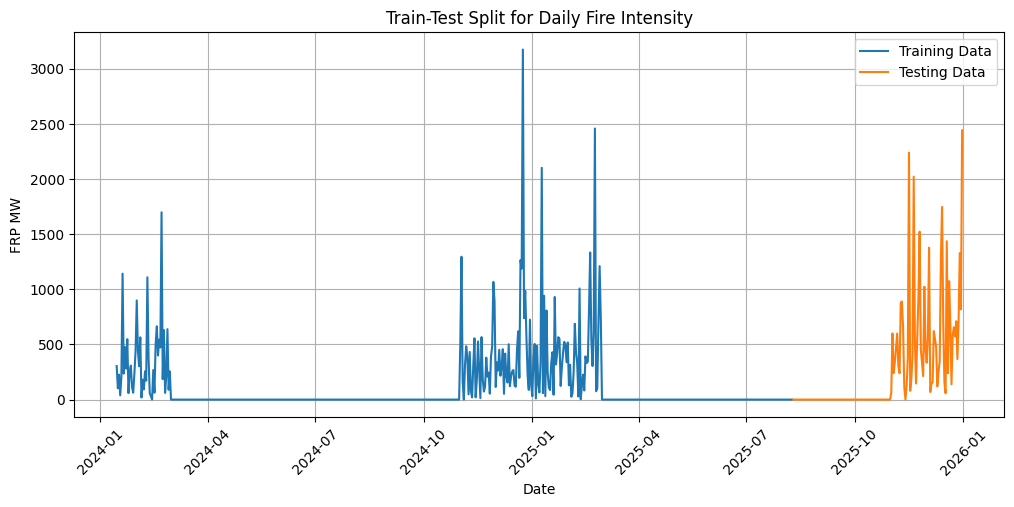

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(train_df["acq_date"], train_df[target_col], label="Training Data")
plt.plot(test_df["acq_date"], test_df[target_col], label="Testing Data")
plt.title("Train-Test Split for Daily Fire Intensity")
plt.xlabel("Date")
plt.ylabel("FRP MW")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## 13. Evaluation Function

The forecasting models are evaluated using common error metrics.

Mean Absolute Error shows the average size of prediction errors. Root Mean Squared Error gives more weight to larger errors. Mean Absolute Percentage Error shows the percentage error, but it must be interpreted carefully when actual values are close to zero.

In [20]:
def evaluate_forecast(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    non_zero = actual != 0
    if non_zero.sum() > 0:
        mape = np.mean(np.abs((actual[non_zero] - predicted[non_zero]) / actual[non_zero])) * 100
    else:
        mape = np.nan

    return mae, rmse, mape

## 14. Baseline Model 1: Naive Forecast

The naive forecast uses the previous day's fire intensity as the prediction for the next day. This is a simple but important baseline because advanced forecasting models should ideally perform better than this approach.

In [21]:
naive_predictions = test_df["frp_lag_1"].values

naive_mae, naive_rmse, naive_mape = evaluate_forecast(
    test_df[target_col],
    naive_predictions
)

print("Naive Forecast Results")
print("MAE:", naive_mae)
print("RMSE:", naive_rmse)
print("MAPE:", naive_mape)

Naive Forecast Results
MAE: 214.21229166666663
RMSE: 463.07008568943064
MAPE: 173.82821864048935


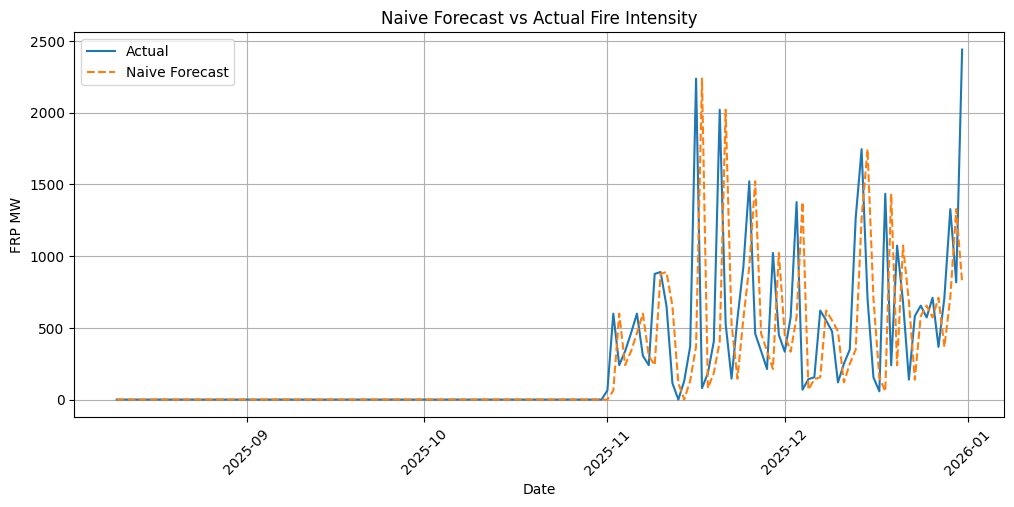

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(test_df["acq_date"], test_df[target_col], label="Actual")
plt.plot(test_df["acq_date"], naive_predictions, label="Naive Forecast", linestyle="--")
plt.title("Naive Forecast vs Actual Fire Intensity")
plt.xlabel("Date")
plt.ylabel("FRP MW")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## 15. Baseline Model 2: Seven-Day Moving Average Forecast

The seven-day moving average forecast uses the average fire intensity from the previous seven days. This method smooths short-term fluctuations and provides a simple reference model for comparison.

In [23]:
moving_avg_predictions = test_df["frp_rolling_7_mean"].values

ma_mae, ma_rmse, ma_mape = evaluate_forecast(
    test_df[target_col],
    moving_avg_predictions
)

print("Seven-Day Moving Average Forecast Results")
print("MAE:", ma_mae)
print("RMSE:", ma_rmse)
print("MAPE:", ma_mape)

Seven-Day Moving Average Forecast Results
MAE: 175.3948611111111
RMSE: 370.1918536944752
MAPE: 132.8600961081496


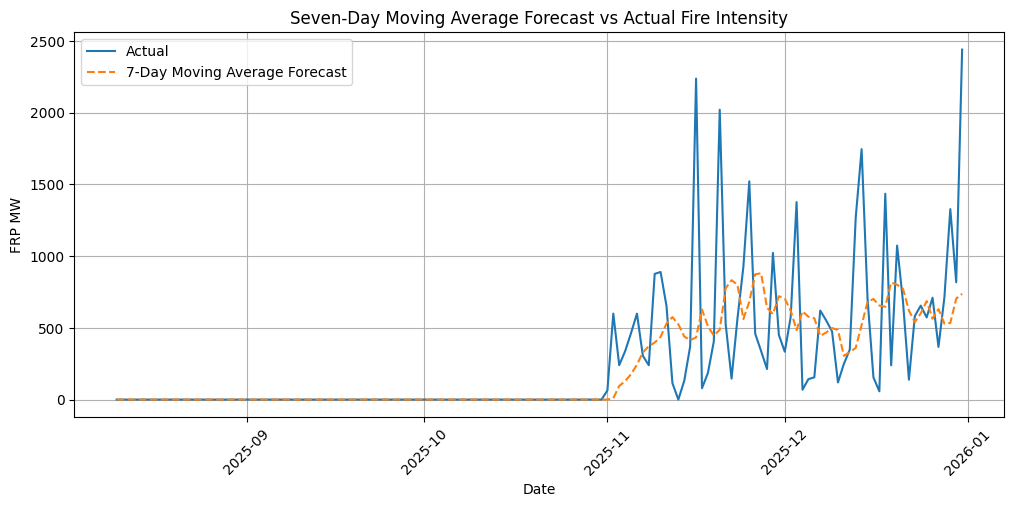

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(test_df["acq_date"], test_df[target_col], label="Actual")
plt.plot(test_df["acq_date"], moving_avg_predictions, label="7-Day Moving Average Forecast", linestyle="--")
plt.title("Seven-Day Moving Average Forecast vs Actual Fire Intensity")
plt.xlabel("Date")
plt.ylabel("FRP MW")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## 16. Baseline Model 3: Linear Regression with Lag Features

A simple Linear Regression model is trained using lag, rolling average, weather, and calendar features. This model gives a machine learning baseline that can be compared with both simple statistical baselines and future LSTM models.

In [25]:
feature_columns = [
    "event_count",
    "avg_brightness_k",
    "avg_temp_max_c",
    "avg_wind_max_kmh",
    "avg_precip_mm",
    "avg_humidity_pct",
    "day_of_week",
    "month",
    "is_weekend",
    "frp_lag_1",
    "frp_lag_3",
    "frp_lag_7",
    "frp_rolling_3_mean",
    "frp_rolling_7_mean",
    "frp_rolling_14_mean"
]

X_train = train_df[feature_columns]
y_train = train_df[target_col]

X_test = test_df[feature_columns]
y_test = test_df[target_col]

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_mae, lr_rmse, lr_mape = evaluate_forecast(y_test, lr_predictions)

print("Linear Regression Forecast Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("MAPE:", lr_mape)

Linear Regression Forecast Results
MAE: 99.67548838282109
RMSE: 225.05953650045095
MAPE: 58.675309368802786


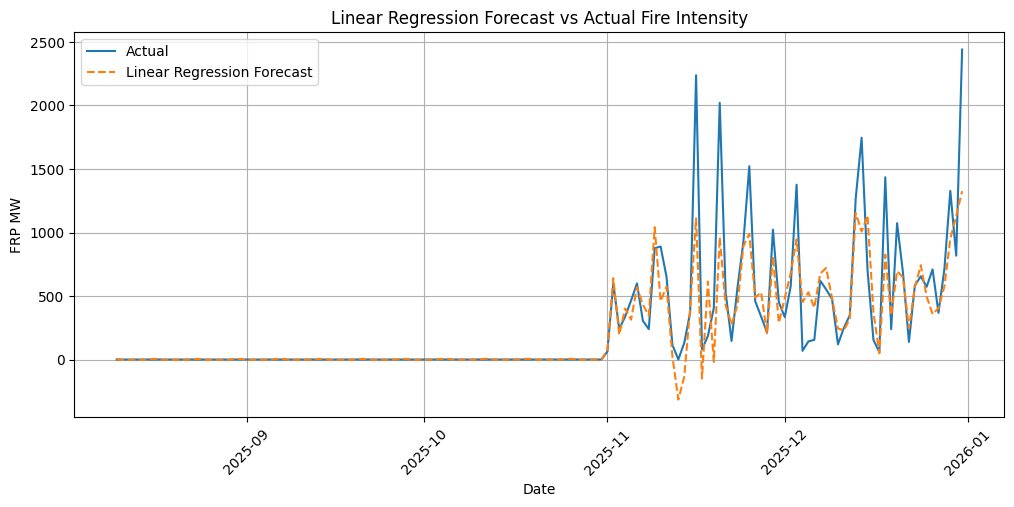

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(test_df["acq_date"], y_test.values, label="Actual")
plt.plot(test_df["acq_date"], lr_predictions, label="Linear Regression Forecast", linestyle="--")
plt.title("Linear Regression Forecast vs Actual Fire Intensity")
plt.xlabel("Date")
plt.ylabel("FRP MW")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## 17. Model Comparison

The forecasting models are compared using MAE, RMSE, and MAPE. The model with lower error values performs better on the test data.

This comparison provides a baseline benchmark that the team can later use when evaluating more advanced models such as LSTM.

In [27]:
results_df = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "7-Day Moving Average",
        "Linear Regression with Lag Features"
    ],
    "MAE": [naive_mae, ma_mae, lr_mae],
    "RMSE": [naive_rmse, ma_rmse, lr_rmse],
    "MAPE": [naive_mape, ma_mape, lr_mape]
})

results_df

,Model,MAE,RMSE,MAPE
0,Naive Forecast,214.212292,463.070086,173.828219
1,7-Day Moving Average,175.394861,370.191854,132.860096
2,Linear Regression with Lag Features,99.675488,225.059537,58.675309


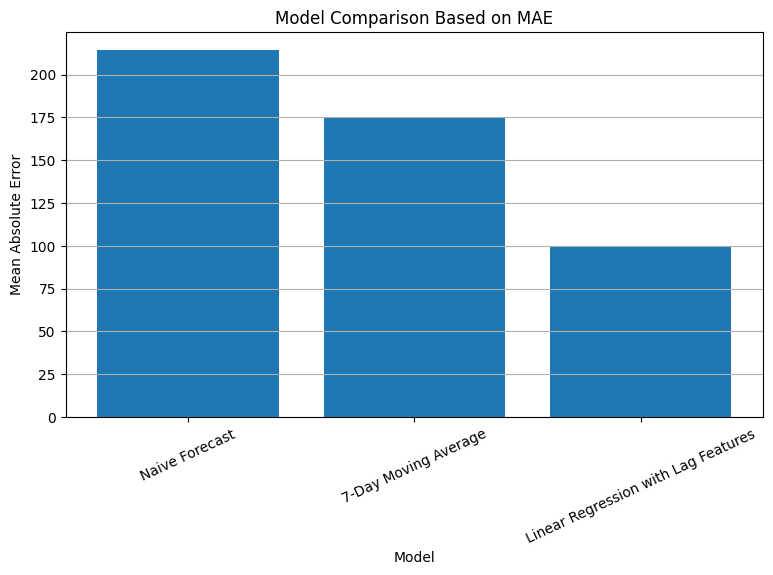

In [28]:
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison Based on MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.show()

## 18. Feature Importance from Linear Regression

The Linear Regression model coefficients are checked to understand which features had stronger influence on the forecast. This is not a perfect feature importance method, but it gives a simple indication of how the model used the prepared variables.

In [29]:
coef_df = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": lr_model.coef_
})

coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Absolute_Coefficient", ascending=False)

coef_df

,Feature,Coefficient,Absolute_Coefficient
0,event_count,126.170646,126.170646
4,avg_precip_mm,-24.435021,24.435021
1,avg_brightness_k,15.618048,15.618048
8,is_weekend,5.615719,5.615719
2,avg_temp_max_c,3.265412,3.265412
5,avg_humidity_pct,2.439628,2.439628
3,avg_wind_max_kmh,-1.053230,1.053230
7,month,0.554518,0.554518
6,day_of_week,0.387681,0.387681
12,frp_rolling_3_mean,0.347807,0.347807


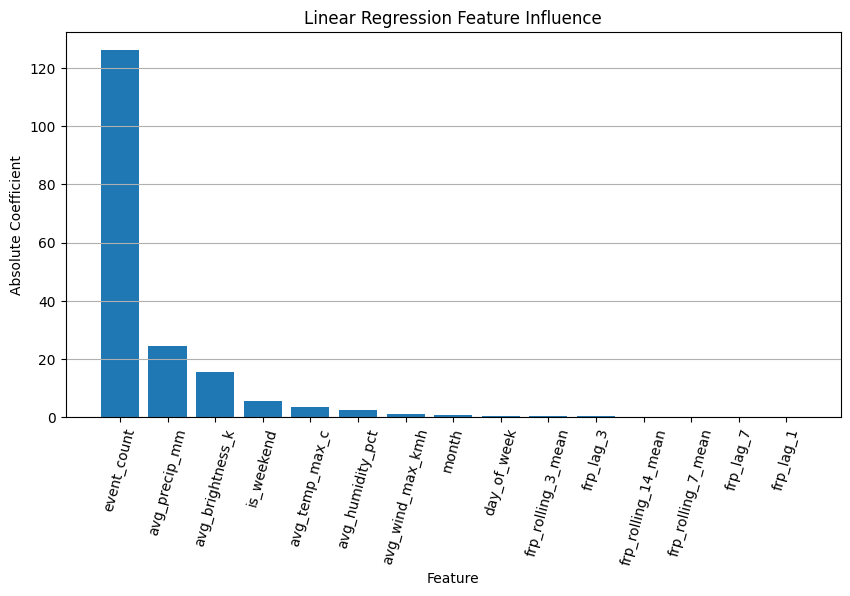

In [30]:
plt.figure(figsize=(10, 5))
plt.bar(coef_df["Feature"], coef_df["Absolute_Coefficient"])
plt.title("Linear Regression Feature Influence")
plt.xlabel("Feature")
plt.ylabel("Absolute Coefficient")
plt.xticks(rotation=75)
plt.grid(axis="y")
plt.show()

## 19. Save Prediction Comparison

The actual and predicted values are saved into a CSV file. This allows the team to review the baseline model outputs and compare them with future LSTM predictions.

In [31]:
prediction_comparison_df = pd.DataFrame({
    "timestamp": test_df["acq_date"].values,
    "location": test_df["region"].values,
    "actual_frp_mw": y_test.values,
    "naive_prediction": naive_predictions,
    "moving_average_prediction": moving_avg_predictions,
    "linear_regression_prediction": lr_predictions
})

prediction_comparison_df["linear_regression_absolute_error"] = (
    prediction_comparison_df["actual_frp_mw"] - prediction_comparison_df["linear_regression_prediction"]
).abs()

prediction_comparison_df.head()

,timestamp,location,actual_frp_mw,naive_prediction,moving_average_prediction,linear_regression_prediction,linear_regression_absolute_error
0,2025-08-10,Australia,0.0,0.0,0.0,4.386165,4.386165
1,2025-08-11,Australia,0.0,0.0,0.0,-3.555643,3.555643
2,2025-08-12,Australia,0.0,0.0,0.0,-3.167961,3.167961
3,2025-08-13,Australia,0.0,0.0,0.0,-2.780280,2.780280
4,2025-08-14,Australia,0.0,0.0,0.0,-2.392599,2.392599


In [32]:
prediction_comparison_df.to_csv("wildfire_baseline_predictions_abin.csv", index=False)

print("Prediction comparison saved as wildfire_baseline_predictions_abin.csv")

Prediction comparison saved as wildfire_baseline_predictions_abin.csv


## 21. Limitations and Future Work

This notebook is designed as a baseline contribution so the models are intentionally simple. The results should not be treated as final production-level wildfire predictions.

One limitation is that the current workflow focuses only on Australia. Future work could include multiple regions and encode location as a model feature. Another limitation is that misinformation-related features are not included yet. These could be added later if the team creates or provides a relevant misinformation dataset.

Future improvements could include SARIMA, Prophet, Random Forest, XGBoost, or LSTM. The prepared feature dataset can also be adapted into sequence format for the team's LSTM pipeline.